# From SPO+ to simulation-assisted stochastic optimization

### Presbitero et al. (2025), and what it shares with tutorial 1

[Tutorial 1](01_pyepo_spo.ipynb) ended at a wall. PyEPO's SPO+ needs an
objective that is **linear in the predicted cost vector** over a **fixed**
feasible set. That covered a one-shot allocation. It does not cover a *policy*:
order some stock now, watch what sells, reorder later, stop before the season
ends — where the cost comes out of a simulator with branches, lead times and
returns, not a dot product.

This tutorial works through a paper that solves exactly that problem in
production, rebuilds it in miniature on the same simulated world, and then
draws the connections back.

> **A. Presbitero et al.**, *"A practical approach to replenishment
> optimization with extended (R,s,Q) policy and probabilistic models"*,
> *Scientific Reports* **15**:44225 (2025).
> [doi:10.1038/s41598-025-32537-2](https://doi.org/10.1038/s41598-025-32537-2)
>
> ⚠️ The article carries a published correction
> (*Sci Rep* **16**:4211, 30 January 2026). Some figures differ between the
> original PDF and the corrected record — for instance the reported correlation
> between forecast WAPE and profit uplift is −0.85 in the original and −0.71 in
> the corrected version. Quote the corrected article.

The system is Zalando's **ZEOS Inventory Optimization Tool**, serving roughly
800 merchants. Its architecture is three components:

1. a **probabilistic forecasting engine** (LightGBM + conformal calibration,
   producing 39 quantiles from 2.5% to 97.5%);
2. a **discrete-event simulation** that maps a candidate policy to a
   *distribution* over costs;
3. a **black-box optimizer** (SHGO) that minimises a risk-aware functional of
   that distribution.

We have (1) already, from tutorial 1. This notebook builds (2) and (3).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})

from srsim.pipeline import build_world

world = build_world()      # the same cached world as tutorial 1 — this notebook stands alone
print(f"evaluation weeks {world.config.eval_start}+ | {len(world.test):,} SKU-weeks")

evaluation weeks 78+ | 4,263 SKU-weeks


## 1. The decision: an extended $(R, s, Q)$ policy

The classical $(R, s, Q)$ rule says: every $R$ weeks, if stock has fallen to or
below the reorder point $s$, order a fixed quantity $Q$. The paper's
contribution is to extend it with three parameters aimed at the shape of a
product's life:

$$\theta = (t_0,\; Q_0,\; s,\; Q,\; t_{\text{limit}})$$

| | |
|---|---|
| $t_0$ | when to place an initial "kickstart" order — constrained by $t_0 \ge L$, the lead time |
| $Q_0$ | how big that initial order is — strategic positioning ahead of demand |
| $s, Q$ | the ordinary reorder rule thereafter |
| $t_{\text{limit}}$ | an ordering cutoff, so the policy stops buying stock it cannot sell before the season ends |

$R$ is fixed operationally rather than optimized. Only $(t_0, Q_0)$ are shown
to merchants; the rest is internal.

Note what kind of object this is. In tutorial 1 the decision was a vector $w$ —
how many units of each item, decided once. Here the decision is **five numbers
that define a rule**, and the rule reacts to whatever the world does inside the
simulation. That is the step from a solution to a policy.

## 2. The evaluator: $C(\theta, \omega)$

A *scenario* $\omega$ is one joint realisation of everything the policy cannot
control over a 12-week horizon:

$$\omega = (d_1 \ldots d_T;\ L_1 \ldots L_T;\ r_1 \ldots r_T)$$

— a demand path, the lead time an order placed in each week would experience
(gamma-distributed, per the paper), and the delay before returned units come
back into stock.

The simulator is then a **deterministic** function of $(\theta, \omega)$. All
randomness lives in the scenario; none lives in the simulator. Within each week
the paper's event order is: half of scheduled inbound and expected returns land
before demand is served, demand is filled from stock with unmet demand lost,
the other half lands after, costs accrue on end-of-week state, and the policy
is reviewed.

Determinism is not an aesthetic preference. It is what lets us reuse one
scenario set across every candidate policy, which is what makes the objective
surface stable enough for a gradient-free optimizer to work on. So it gets a
test, not a comment.

In [2]:
from srsim.des import CostParams, Policy, cost_percentile, service_metrics, simulate_costs
from srsim.scenarios import make_scenarios_from_truth

COSTS = CostParams()
demo = make_scenarios_from_truth(np.full(12, 10.0), np.full(12, 0.25), 500, seed=7)
demo_policy = Policy(t0=1, q0=40, s=15, q=25, t_limit=10)

first = simulate_costs(demo_policy, demo, COSTS, initial_stock=15.0)
second = simulate_costs(demo_policy, demo, COSTS, initial_stock=15.0)
print("C(theta, omega) is bit-identical across calls:", np.array_equal(first, second))

total, parts = simulate_costs(demo_policy, demo, COSTS, 15.0, return_components=True)
breakdown = pd.Series({k: v.mean() for k, v in parts.items() if not k.startswith("_")})
print(f"\nmean cost {total.mean():.1f}, of which:")
print(breakdown.round(1).to_string())

C(theta, omega) is bit-identical across calls: True

mean cost 347.9, of which:
holding        42.0
inbound        17.8
outbound       31.8
returns        11.9
lost_sales    244.3


### One policy, a distribution of outcomes

This is the heart of the method. A policy does not have *a* cost; it has a cost
*distribution*, and the shape of that distribution is asymmetric. Understocking
a product that turns out to be a winner costs lost margin, which is large;
overstocking costs holding, which is small and bounded.

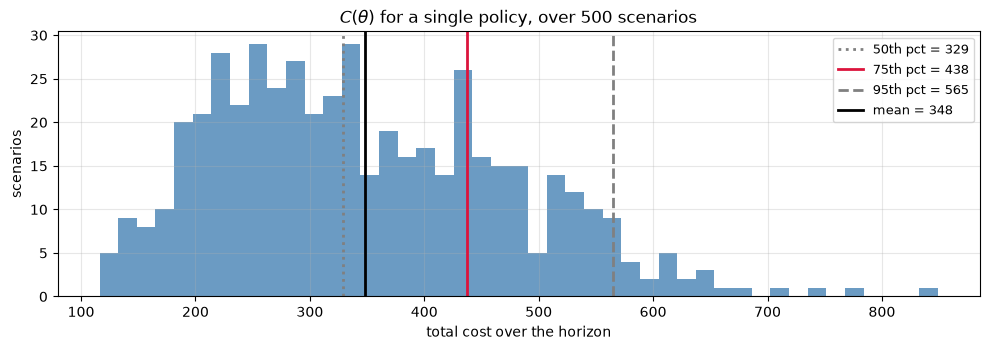

In [3]:
fig, ax = plt.subplots()
ax.hist(total, bins=45, alpha=0.8, color="steelblue")
for level, colour, style in [(50, "grey", ":"), (75, "crimson", "-"), (95, "grey", "--")]:
    v = cost_percentile(total, level)
    ax.axvline(v, color=colour, ls=style, lw=2, label=f"{level}th pct = {v:.0f}")
ax.axvline(total.mean(), color="black", lw=2, label=f"mean = {total.mean():.0f}")
ax.set(xlabel="total cost over the horizon", ylabel="scenarios",
       title="$C(\\theta)$ for a single policy, over 500 scenarios")
ax.legend(fontsize=9)
plt.tight_layout()

The paper minimises the **75th percentile** of this distribution rather than
its mean — a tractable stand-in for a CVaR-style criterion. Optimising the mean
quietly accepts the fat right tail; optimising a high percentile buys
robustness against the scenarios that hurt.

The paper's stated reasoning for 75 specifically: it approximates CVaR, matches
industry service-level targets of 75–95%, and stays numerically stable, whereas
percentiles above ~80–85% get unstable in finite-sample stochastic programming.
Their own sensitivity analysis found the 90th percentile gave slightly higher
GMV but worse service and fewer merchants better off.

## 3. Scenarios: common random numbers, and three scenario sets

Demand paths come from the J-QPD fitted in tutorial 1, by inverse transform:
$d = Q(u)$, $u \sim U(0,1)$. This is where that output contract pays off — the
forecast is *already* a sampler.

Two disciplines, both load-bearing:

**Common random numbers.** The scenario set is generated once and reused across
every candidate policy. Re-drawing per evaluation would make the objective
stochastic and a gradient-free optimizer would chase sampling noise.

**A strict optimize/evaluate split.** Policies are tuned on $\Omega_{opt}$
(500 scenarios, as in the paper) and reported on a fresh $\Omega_{eval}$.
Scoring a policy on the scenarios it was tuned against overstates it.

### A third scenario set the paper could not have

Here is where a simulator buys something a production system cannot get.
$\Omega_{opt}$ and $\Omega_{eval}$ are **both drawn from the fitted forecast**,
so the gap between them measures optimizer overfitting *and nothing else*. If
the forecast is wrong, both are wrong together.

Because we know the true data-generating process, we can add
$\Omega_{true}$ — scenarios drawn from reality — and decompose the total error:

| transition | what it isolates |
|---|---|
| $\Omega_{opt} \to \Omega_{eval}$ | **SAA optimism** — the optimizer fitting scenario noise |
| $\Omega_{eval} \to \Omega_{true}$ | **forecast misspecification** — the forecast being wrong |

We will find these two are not remotely the same size, which has a direct
practical implication for where to spend effort.

## 4. The optimizer

$$\theta^\star = \arg\min_\theta \; Q_{75}\big[\,C(\theta, \omega) : \omega \in \Omega_{opt}\big]$$

solved with SHGO, a gradient-free global optimizer, independently per SKU —
the paper assumes no cannibalisation between SKUs, which makes the whole thing
embarrassingly parallel. We use `joblib` across cores for the same reason the
paper reaches for Kubernetes.

One practical wrinkle the paper does not dwell on: $t_0$ and $t_{\text{limit}}$
are **week indices**. Rounding them inside a continuous objective creates flat
plateaus that defeat SHGO's local refinement, so we enumerate them on a small
outer grid and let SHGO work on the genuinely continuous $(Q_0, s, Q)$.

## 5. The ablation

We run the paper's own ablation, plus its classical baselines. Every arm is
tuned on the *same* $\Omega_{opt}$ with the *same* costs — the methodological
parity the paper insists on — and scored on the same held-out sets.

| arm | forecast | objective |
|---|---|---|
| **Q-PCTL** | probabilistic | 75th percentile — the full model |
| **Q-MEAN** | probabilistic | mean |
| **P-PCTL** | point forecast | 75th percentile |
| **(s,S)** | — | grid-tuned classical order-up-to |
| **base-stock** | — | grid-tuned periodic order-up-to |
| **newsvendor** | probabilistic | the myopic single-period answer **from tutorial 1** |

That last arm is the literal bridge between the two notebooks: tutorial 1's
closed-form critical fractile, dropped into this simulator so it can be scored
by the same cost functional as everything else.

In [4]:
from srsim.experiment import run_ablation

counts = world.test.groupby(["P_ID", "L_ID"]).size()
eligible = counts[counts >= 12].index
lifecycle_flag = world.test.groupby(["P_ID", "L_ID"]).has_lifecycle.first()

rng = np.random.default_rng(5)
lifecycle = [k for k in eligible if lifecycle_flag[k]]
steady = [k for k in eligible if not lifecycle_flag[k]]
selection = ([lifecycle[i] for i in rng.choice(len(lifecycle), 10, replace=False)]
             + [steady[i] for i in rng.choice(len(steady), 10, replace=False)])

results = run_ablation(world, selection, n_jobs=4, n_opt=500, n_eval=2000, lead_mean=1.0)
results["regime"] = np.where(
    pd.MultiIndex.from_frame(results[["P_ID", "L_ID"]]).isin(lifecycle), "lifecycle", "steady"
)
print(f"{results.P_ID.nunique()} products across {len(selection)} SKU-locations, 6 arms each")

18 products across 20 SKU-locations, 6 arms each


In [5]:
ORDER = ["Q-PCTL", "Q-MEAN", "P-PCTL", "(s,S)", "base-stock", "newsvendor"]
summary = (results.groupby("arm")[["cost_p75_opt", "cost_p75_eval", "cost_p75_true",
                                   "fill_rate_true", "availability_true"]]
           .mean().reindex(ORDER))
summary["vs Q-PCTL"] = (summary.cost_p75_true / summary.loc["Q-PCTL", "cost_p75_true"] - 1) * 100
summary.round(3)

,cost_p75_opt,cost_p75_eval,cost_p75_true,fill_rate_true,availability_true,vs Q-PCTL
arm,,,,,,
Q-PCTL,391.207,402.315,513.575,0.854,0.793,0.000
Q-MEAN,396.594,401.559,510.720,0.849,0.785,-0.556
P-PCTL,520.682,528.060,769.598,0.688,0.563,49.851
"(s,S)",454.124,467.580,576.617,0.791,0.735,12.275
base-stock,450.777,460.491,537.740,0.798,0.743,4.705
newsvendor,476.445,482.127,525.705,0.821,0.786,2.362


### What reproduces, and what does not

**The point-versus-distribution step reproduces, emphatically.** P-PCTL — the
arm that keeps everything except the demand distribution, replacing it with a
point forecast — is far and away the worst, at a large cost premium and a fill
rate some 15 points below the others. In the paper this is the same story: GMV
uplift of 6.37% for P-PCTL against 19.02% once the distribution is used. If you
take one thing from this notebook, it is that **feeding an optimizer a point
forecast throws away most of the value**, and it does so silently.

**The extended policy beats the classical baselines**, as in the paper, where
it outperformed the best classical comparator (tuned $(s,S)$) by 8.72
percentage points of GMV uplift.

**The mean-versus-percentile step does not reproduce.** Q-PCTL and Q-MEAN come
out within about a percent of each other here, with no consistent winner, where
the paper found a clear advantage for the percentile objective (22.11% vs
19.02%). We report that as measured. Plausible reasons: our horizon is a single
12-week window rather than 12 monthly execution dates, our cost asymmetry is
milder, and 20 SKUs is a small sample for a difference of that size. The
honest summary is that in this setting the risk-aware objective is not doing
much work, and the distributional forecast is doing almost all of it.

A note on scale, so nothing here is over-read: the paper covers ~800 merchants
and a full year of monthly execution dates. Twenty SKUs reproduces the
*mechanism*, not the *result*. None of our numbers should be placed next to
theirs.

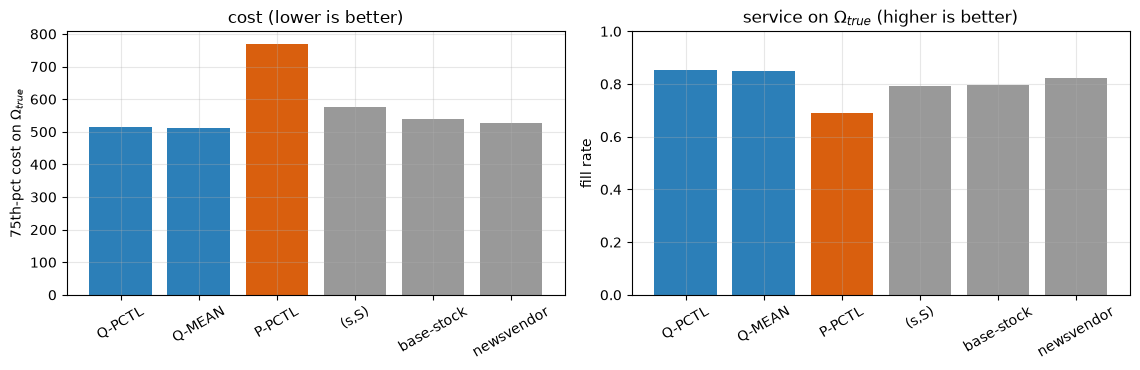

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
colours = ["#2c7fb8" if a in ("Q-PCTL", "Q-MEAN") else "#d95f0e" if a == "P-PCTL" else "#999999"
           for a in ORDER]
axes[0].bar(ORDER, summary.cost_p75_true, color=colours)
axes[0].set(ylabel="75th-pct cost on $\\Omega_{true}$", title="cost (lower is better)")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(ORDER, summary.fill_rate_true, color=colours)
axes[1].set(ylabel="fill rate", title="service on $\\Omega_{true}$ (higher is better)",
            ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()

## 6. Decomposing the error: optimism versus misspecification

Now the decomposition that a production system cannot perform. For each arm we
have its cost on the scenarios it was tuned on, on fresh scenarios from the
same forecast, and on scenarios from the true process.

In [7]:
decomp = summary[["cost_p75_opt", "cost_p75_eval", "cost_p75_true"]].copy()
decomp["SAA optimism %"] = (decomp.cost_p75_eval / decomp.cost_p75_opt - 1) * 100
decomp["forecast error %"] = (decomp.cost_p75_true / decomp.cost_p75_eval - 1) * 100
decomp.round(2)

,cost_p75_opt,cost_p75_eval,cost_p75_true,SAA optimism %,forecast error %
arm,,,,,
Q-PCTL,391.21,402.32,513.57,2.84,27.65
Q-MEAN,396.59,401.56,510.72,1.25,27.18
P-PCTL,520.68,528.06,769.60,1.42,45.74
"(s,S)",454.12,467.58,576.62,2.96,23.32
base-stock,450.78,460.49,537.74,2.15,16.78
newsvendor,476.45,482.13,525.70,1.19,9.04


The two gaps are not the same order of magnitude. Re-solving on fresh scenarios
from the same forecast costs a few percent — that is real SAA optimism, and it
is why the optimize/evaluate split exists. Moving to scenarios from the *true*
process costs several times more.

**Almost all of the error is the forecast being wrong, not the optimizer
overfitting.** Which tells you where to spend the next month of engineering.

This is also the mechanism behind one of the paper's most quoted findings: a
strong negative correlation between forecast WAPE and financial uplift
(−0.71 in the corrected article). They observe that correlation across
merchants. We can do better than observe it — we can *cause* it, by
deliberately degrading the forecast and watching the decision quality fall.

In [8]:
from srsim.forecast import QPDForecast, make_forecast

def degrade(forecast: QPDForecast, factor: float) -> QPDForecast:
    """Shrink the forecast toward a flat, uninformative one.

    factor = 0 leaves it alone; factor = 1 replaces every SKU-week by the global
    average, which is the least informative forecast with the right overall level.
    """
    blend = lambda q: (1 - factor) * q + factor * float(np.mean(q))
    return make_forecast(blend(forecast.q_low), blend(forecast.q_median),
                         blend(forecast.q_high), alpha=forecast.alpha)

import copy

wape_rows = []
subset = selection[:8]
for factor in (0.0, 0.35, 0.7, 1.0):
    degraded_world = copy.copy(world)
    degraded_world.forecast = degrade(world.forecast, factor)
    wape = float(np.abs(degraded_world.forecast.q_median - world.test.sales.to_numpy()).sum()
                 / world.test.sales.to_numpy().sum())
    out = run_ablation(degraded_world, subset, n_jobs=4, n_opt=300, n_eval=1000,
                       lead_mean=1.0, arms=("Q-PCTL",))
    wape_rows.append({"degradation": factor, "forecast WAPE": wape,
                      "cost on $\\Omega_{true}$": out.cost_p75_true.mean(),
                      "fill rate": out.fill_rate_true.mean()})
wape_frame = pd.DataFrame(wape_rows).set_index("degradation")
wape_frame.round(3)

,forecast WAPE,cost on $\Omega_{true}$,fill rate
degradation,,,
0.00,0.615,212.403,0.874
0.35,0.632,215.398,0.916
0.70,0.683,232.675,0.932
1.00,0.749,253.785,0.935


correlation between forecast WAPE and realised cost: +0.999
(the paper reports rho = -0.71 between WAPE and profit *uplift*; uplift moves
 opposite to cost, so a positive correlation here is the same phenomenon)


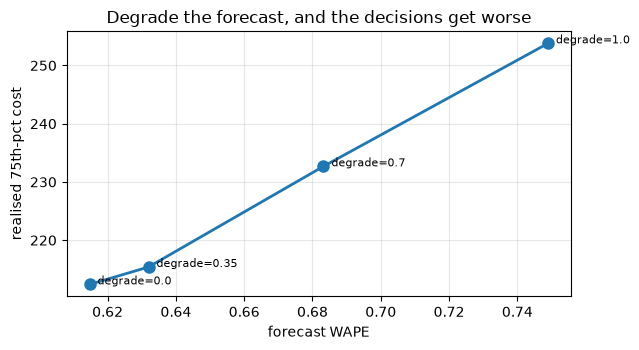

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(wape_frame["forecast WAPE"], wape_frame["cost on $\\Omega_{true}$"], "o-", lw=2, ms=8)
for factor, row in wape_frame.iterrows():
    ax.annotate(f"  degrade={factor}", (row["forecast WAPE"], row["cost on $\\Omega_{true}$"]), fontsize=8)
ax.set(xlabel="forecast WAPE", ylabel="realised 75th-pct cost",
       title="Degrade the forecast, and the decisions get worse")
corr = float(np.corrcoef(wape_frame["forecast WAPE"], wape_frame["cost on $\\Omega_{true}$"])[0, 1])
print(f"correlation between forecast WAPE and realised cost: {corr:+.3f}")
print("(the paper reports rho = -0.71 between WAPE and profit *uplift*; uplift moves")
print(" opposite to cost, so a positive correlation here is the same phenomenon)")
plt.tight_layout()

One counter-intuitive column deserves an explanation, because it is a trap.
As the forecast degrades, the **fill rate goes up** while cost also goes up.
Flattening the forecast toward the global average raises the predicted demand
for most SKUs (the average is pulled up by the big ones), so the policy
over-orders: service improves and holding costs balloon. Service metrics on
their own are not a proxy for decision quality either — you can always buy fill
rate with inventory. Only the cost functional scores both sides of the trade.

(These cost levels are lower than the ablation table's because this sweep runs
on a smaller subset of SKUs; only the trend across rows is meaningful.)

The paper's correlation is observational — across merchants, better forecasts
came with better outcomes. Here the arrow of causation is ours by construction:
nothing changed except forecast quality, and the decisions got worse. The
optimizer is only ever as good as the distribution you hand it.

## 7. Where the extended policy's extra parameters earn their keep

The paper motivates $t_0$, $Q_0$ and $t_{\text{limit}}$ by **short product
lifecycles and pronounced seasonality**. That motivation is testable, because
our simulator has both kinds of product: some with a launch-peak-decline
lifecycle, some in steady state.

Textbook inventory theory says a base-stock policy is very hard to beat in
steady state. So if the paper's framing is right, the extended policy's
advantage should be concentrated in the lifecycle SKUs and largely absent from
the steady-state ones. That is a falsifiable prediction, so let us check it.

In [10]:
by_regime = (results.groupby(["regime", "arm"])["cost_p75_true"].mean()
             .unstack().reindex(columns=ORDER))
relative = by_regime.div(by_regime["Q-PCTL"], axis=0).sub(1).mul(100)
print("cost relative to Q-PCTL, % (positive = worse than Q-PCTL)")
relative.round(2)

cost relative to Q-PCTL, % (positive = worse than Q-PCTL)


arm,Q-PCTL,Q-MEAN,P-PCTL,"(s,S)",base-stock,newsvendor
regime,,,,,,
lifecycle,0.0,1.04,34.72,18.67,17.69,26.76
steady,0.0,-0.95,53.64,10.67,1.46,-3.74


The split is decisive, and it lands where the paper says it should.

On **lifecycle** SKUs the extended policy is worth a lot: base-stock costs
about 18% more, the tuned $(s,S)$ about 19% more, and tutorial 1's myopic
newsvendor about 27% more. On **steady-state** SKUs almost all of that
advantage evaporates — base-stock comes within about 1.5%, and the myopic
newsvendor is actually slightly *better* than the full machinery.

That is not a disappointing result; it is the correct one, and it is worth
stating plainly: **in steady state, a well-tuned base-stock policy is very hard
to beat, and the elaborate method does not beat it.** The extra parameters buy
you something precisely when demand has a shape to be positioned against — a
launch to stock up for, a decline to stop ordering into. Zalando's articles are
seasonal with short lifecycles, which is exactly that regime.

The general lesson for reading any inventory paper: ask what the demand looked
like before believing that a policy class transfers.

### A structural caveat, found the hard way

There is one more thing worth reporting, because it is the kind of detail that
decides whether a policy works and never appears in a summary table.

The paper's rule triggers an ongoing order when **on-hand stock** falls to or
below $s$ *and nothing is already in transit*. That in-transit guard exists
because the trigger ignores the pipeline — without it the policy would order
the same replenishment repeatedly while waiting for delivery.

But the guard also throttles the policy: while an order is in flight, no
further order can be placed. So when **lead time exceeds the review period**,
the policy simply cannot reorder often enough, and a plain base-stock policy —
which tops up from inventory *position* every review, with no such guard —
beats it comfortably.

In [11]:
from srsim.optimize import default_bounds, optimize_policy, tune_order_up_to
from srsim.experiment import sku_rows
from srsim.scenarios import make_scenarios_from_qpd

from joblib import Parallel, delayed


def lead_time_comparison(p, l, lead):
    """Extended (R,s,Q) vs base-stock for one SKU at one lead time."""
    rows = sku_rows(world.test, int(p), int(l), 12)
    median = world.forecast.q_median[rows]
    weekly, init = float(median.mean()), float(1.5 * np.median(median))
    omega_opt = make_scenarios_from_qpd(world.forecast, rows, 300, seed=11, lead_mean=lead)
    omega_true = make_scenarios_from_truth(
        world.test.lam.to_numpy()[rows], world.test.dispersion.to_numpy()[rows],
        1000, seed=12, lead_mean=lead,
    )
    bounds = default_bounds(weekly, 12, lead_weeks=max(1, int(round(lead))))
    best = optimize_policy(omega_opt, COSTS, bounds, initial_stock=init, percentile=75.0)
    base = tune_order_up_to(
        omega_opt, COSTS, init, np.linspace(0, 4 * weekly, 9),
        np.linspace(weekly, 9 * weekly, 12), horizon=12, always_order=True,
    )
    return {
        "lead time (weeks)": lead,
        "extended (R,s,Q)": service_metrics(best.policy, omega_true, COSTS, init)["cost_p75"],
        "base-stock": service_metrics(base, omega_true, COSTS, init)["cost_p75"],
    }


pairs = [(p, l, lead) for lead in (1.0, 1.5, 2.0) for p, l in selection[:6]]
lead_raw = Parallel(n_jobs=4)(delayed(lead_time_comparison)(p, l, lead) for p, l, lead in pairs)
lead_frame = pd.DataFrame(lead_raw).groupby("lead time (weeks)").mean()
lead_frame["extended is better by %"] = (lead_frame["base-stock"] / lead_frame["extended (R,s,Q)"] - 1) * 100
lead_frame.round(2)

,"extended (R,s,Q)",base-stock,extended is better by %
lead time (weeks),,,
1.0,181.27,206.81,14.09
1.5,230.12,229.32,-0.35
2.0,247.36,244.27,-1.25


With a review period of 2 weeks: at a 1-week lead time the extended policy wins
clearly; by a 2-week lead time the advantage is gone. The policy's structure
and the operating cadence have to be designed together, and a paper's headline
result carries its operating regime with it.

This is not a criticism of the paper — it is a reminder that reproducing a
method means reproducing its context, and that reading a result without its
regime is how methods get misapplied.

---
# 8. The connections

Both tutorials attack the same underlying question — *how do you make a
forecast serve a decision?* — and answer it in two genuinely different places.

| | **PyEPO / SPO+** (tutorial 1) | **ZEOS** (tutorial 2) |
|---|---|---|
| decision object | a solution vector $w$, decided once | policy parameters $\theta$, reacting over time |
| uncertainty enters as | a point cost vector $\hat{c}(x)$ | a full distribution, sampled into scenarios |
| objective | linear: $c^\top w$ | a non-convex simulator $C(\theta, \omega)$ |
| gradients | subgradient through the argmin (SPO+) | none — gradient-free SHGO |
| what is learned | **the forecaster** | **the policy** (the forecaster is trained separately) |
| risk attitude | expected regret | a tail percentile of cost |
| scales with | dataset size | scenarios × candidates × SKUs |

### Three things worth being precise about

**1. They are on different axes, not the same one.** It is tempting to say SPO+
is "worse" because it collapses a distribution to a point. That is backwards.
In tutorial 1's problem the objective is linear in $c$ and the feasible set is
fixed, so $\mathbb{E}[c^\top w] = \mathbb{E}[c]^\top w$ — the conditional mean
is *exactly sufficient*, and SPO+'s job is to learn the right point, not to
preserve a distribution it does not need.

The distribution starts to matter when the objective is **nonlinear in the
uncertainty**, when you are **risk-averse**, or when uncertainty enters the
**constraints**. A multi-week inventory simulation is all three. The paper's
P-PCTL vs Q-PCTL ablation is precisely the first of those, measured — and it
was the largest single effect in both their results and ours.

**2. The newsvendor is the same object in both.** In tutorial 1 the
decision-optimal point forecast turned out to be the critical-fractile
quantile. In tutorial 2 that same quantity is an entire baseline policy, scored
inside the simulator. SPO+ sits at "a point, but the *decision-optimal* point";
ZEOS sits at "the whole distribution, plus a risk functional". Neither
dominates — they assume different things.

**3. Neither substitutes for the other.** SPO+ needs a linear objective, a
fixed feasible set, and a differentiable-enough argmin. ZEOS needs a simulator
and a low-dimensional policy class, and it gets no gradient signal back into
the forecaster at all — which is exactly why the WAPE-versus-uplift correlation
is something the paper can only *observe*. The forecaster is trained on
accuracy and hoped to be useful.

### The merge point

The obvious synthesis is to make the simulator differentiable. If
$C(\theta, \omega)$ is written so that its branches are soft, then gradients
flow not only to $\theta$ but all the way back into the forecaster — and you
get decision-focused *probabilistic* forecasting: a demand model trained so
that the replenishment policy built on it performs well, rather than so that
its WAPE is low.

That is the frontier both papers point at, and it is what
[`PLAN.md`](../PLAN.md) in this repository lays out: §1.4 for the
sample-average formulation these scenarios approximate, §5 for the scenario
engine and the $\Omega_{opt}/\Omega_{eval}$ discipline, §12.1 for the JAX
rewrite that makes the evaluator differentiable, and §10 for the step from
static parameters to learned sequential policies.

Everything in these two notebooks is the laptop-scale version of that plan.

In [12]:
print("Tutorial 1  ->  the decision-optimal point forecast is a critical-fractile quantile")
print("Tutorial 2  ->  when the objective is a simulator, you need the whole distribution")
print()
print("Largest single effect measured, in both the paper and here:")
p_pctl = summary.loc["P-PCTL", "cost_p75_true"] / summary.loc["Q-PCTL", "cost_p75_true"] - 1
print(f"  replacing the distribution with a point forecast costs {p_pctl:+.1%}")
print()
print("Where the error actually lives:")
print(f"  SAA optimism    {decomp.loc['Q-PCTL', 'SAA optimism %']:+.1f}%")
print(f"  forecast error  {decomp.loc['Q-PCTL', 'forecast error %']:+.1f}%")

Tutorial 1  ->  the decision-optimal point forecast is a critical-fractile quantile
Tutorial 2  ->  when the objective is a simulator, you need the whole distribution

Largest single effect measured, in both the paper and here:
  replacing the distribution with a point forecast costs +49.9%

Where the error actually lives:
  SAA optimism    +2.8%
  forecast error  +27.7%
